# Notebook 3 — Essais / Modélisation

## Objectif
Essais de modélisation (non cleané).


In [1]:
        import pandas as pd
        import numpy as np
        import matplotlib.pyplot as plt
        import seaborn as sns

        from sklearn.preprocessing import StandardScaler
        from sklearn.cluster import KMeans, MiniBatchKMeans
        from sklearn.metrics import silhouette_score

        base_path = r"C:\Users\mmaslouhi\Documents\Mission - Segmentez des clients d'un site e-commerce\archive"

        orders = pd.read_csv(base_path + r"\olist_orders_dataset.csv")
        order_items = pd.read_csv(base_path + r"\olist_order_items_dataset.csv")
        customers = pd.read_csv(base_path + r"\olist_customers_dataset.csv")
        order_reviews = pd.read_csv(base_path + r"\olist_order_reviews_dataset.csv")


### Fichier commandes

In [2]:
orders_delivered = orders[orders["order_status"] == "delivered"].copy()

order_items["item_total"] = order_items["price"] + order_items["freight_value"]
order_amount = (
    order_items.groupby("order_id", as_index=False)["item_total"]
    .sum()
    .rename(columns={"item_total":"order_amount"})
)

orders_final = orders_delivered.merge(order_amount, on="order_id", how="left")
orders_final["order_purchase_timestamp"] = pd.to_datetime(
    orders_final["order_purchase_timestamp"], errors="coerce"
)

orders_clients = orders_final.merge(
    customers[["customer_id","customer_unique_id"]], on="customer_id", how="left"
).dropna(subset=["order_purchase_timestamp"])

orders_final.shape, orders_clients.shape


((96478, 9), (96478, 10))

### RFM (niveau client)

In [3]:
reference_date = orders_clients["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    orders_clients.groupby("customer_unique_id")
    .agg(
        recency=("order_purchase_timestamp", lambda x: (reference_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("order_amount", "sum")
    )
    .reset_index()
)

(rfm["frequency"].eq(1).mean() * 100).round(2)


np.float64(97.0)

### Prétraitement + choix k (k=5 recommandé mentor)

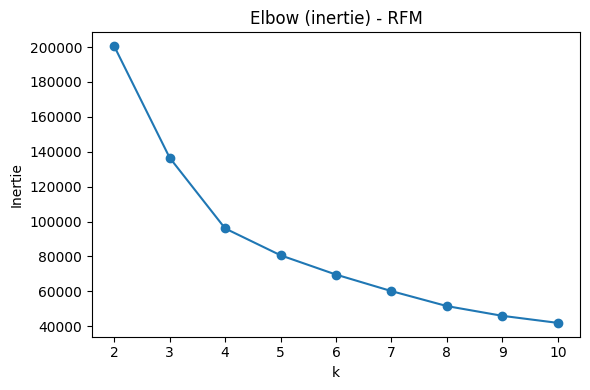

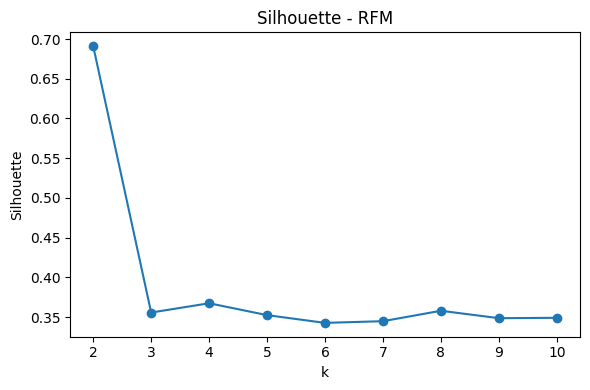

5

In [4]:
rfm["monetary_log"] = np.log1p(rfm["monetary"])
X = rfm[["recency","frequency","monetary_log"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K = range(2, 11)
inertia, sil = [], []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(list(K), inertia, marker="o")
plt.title("Elbow (inertie) - RFM")
plt.xlabel("k")
plt.ylabel("Inertie")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(list(K), sil, marker="o")
plt.title("Silhouette - RFM")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.show()

k_opt = 5
k_opt


### KMeans + MiniBatchKMeans

In [5]:
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
rfm["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

mbk = MiniBatchKMeans(n_clusters=k_opt, random_state=42, batch_size=2048, n_init=10)
rfm["cluster_minibatch"] = mbk.fit_predict(X_scaled)

rfm["cluster_kmeans"].value_counts()


cluster_kmeans
4    28955
2    25508
1    24454
0    11640
3     2801
Name: count, dtype: int64

### Enrichissement reviews + clustering enrichi

In [6]:
order_reviews["review_creation_date"] = pd.to_datetime(order_reviews["review_creation_date"], errors="coerce")

reviews_with_customer = order_reviews.merge(
    orders_clients[["order_id","customer_unique_id"]],
    on="order_id",
    how="left"
)

review_customer = (
    reviews_with_customer.groupby("customer_unique_id", as_index=False)
    .agg(
        avg_review_score=("review_score","mean"),
        nb_reviews=("review_score","count")
    )
)

rfm_enriched = rfm.merge(review_customer, on="customer_unique_id", how="left")
rfm_enriched["avg_review_score"] = rfm_enriched["avg_review_score"].fillna(rfm_enriched["avg_review_score"].mean())
rfm_enriched["nb_reviews"] = rfm_enriched["nb_reviews"].fillna(0)

X2 = rfm_enriched[["recency","frequency","monetary_log","avg_review_score","nb_reviews"]]
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

kmeans_enriched = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
rfm_enriched["cluster_kmeans_enriched"] = kmeans_enriched.fit_predict(X2_scaled)

rfm_enriched["cluster_kmeans_enriched"].value_counts()


cluster_kmeans_enriched
1    30432
2    23986
4    22647
0    13527
3     2766
Name: count, dtype: int64

### Test d’un algorithme alternatif : DBSCAN


DBSCAN est un algorithme de clustering basé sur la densité.
Il permet d’identifier des groupes de points denses et de détecter des points aberrants (bruit).
Contrairement à K-Means, il ne nécessite pas de fixer le nombre de clusters à l’avance.


In [7]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np

# Données utilisées (ex : RFM)
X = rfm[["recency", "frequency", "monetary"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=50)
clusters_dbscan = dbscan.fit_predict(X_scaled)

# Ajouter au dataframe
rfm["cluster_dbscan"] = clusters_dbscan

# Analyse rapide
rfm["cluster_dbscan"].value_counts()


cluster_dbscan
 0    89902
 2     2396
-1      834
 1      226
Name: count, dtype: int64

Avec DBSCAN, une grande partie des clients est classée comme bruit (-1),
ce qui indique une faible densité globale dans l’espace RFM.

Les clusters identifiés sont très déséquilibrés et peu exploitables
pour un usage marketing opérationnel.

DBSCAN est donc moins adapté que K-Means dans ce contexte.
